In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility seeds
np.random.seed(42)
tf.random.set_seed(42)

print("All imports successful!")
print(f"TensorFlow version: {tf.__version__}")

All imports successful!
TensorFlow version: 2.19.0


In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch UCI Heart Disease (Cleveland) dataset
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets.values.ravel()

print(f"Dataset shape : {X.shape}")
print(f"Target shape  : {y.shape}")
print(f"Unique classes: {np.unique(y)}")
print(f"Class counts  : {np.bincount(y.astype(int))}")
print(f"\nMissing values:\n{X.isnull().sum()}")
print(f"\nFeature dtypes:\n{X.dtypes}")

Dataset shape : (303, 13)
Target shape  : (303,)
Unique classes: [0 1 2 3 4]
Class counts  : [164  55  36  35  13]

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Feature dtypes:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


/tmp/ipykernel_374/3335843081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


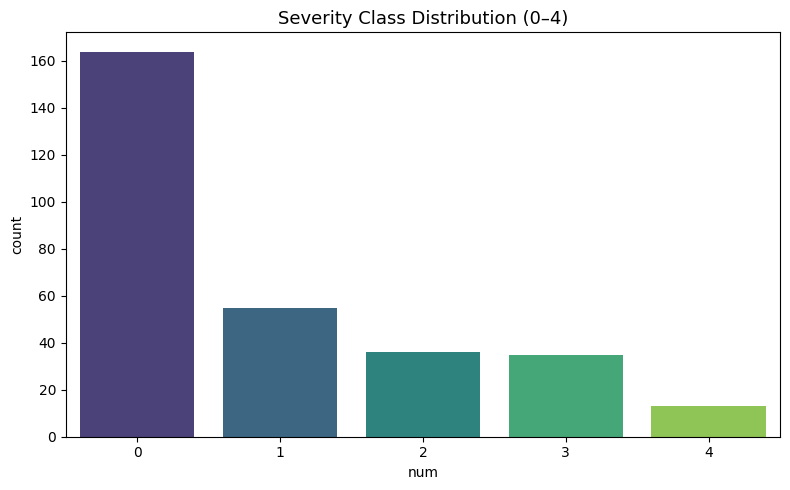

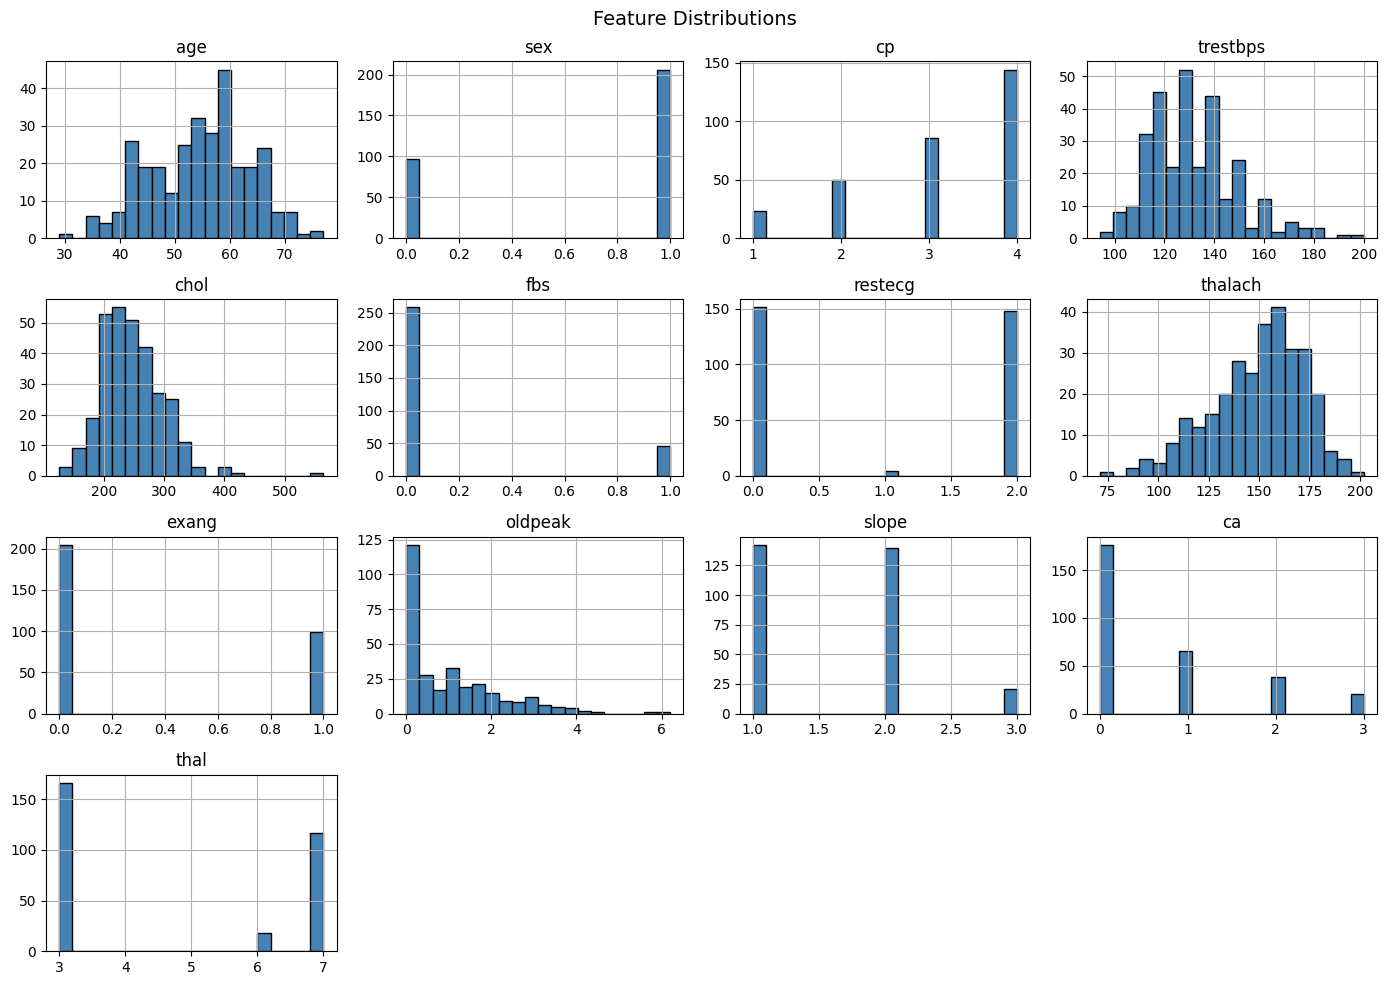

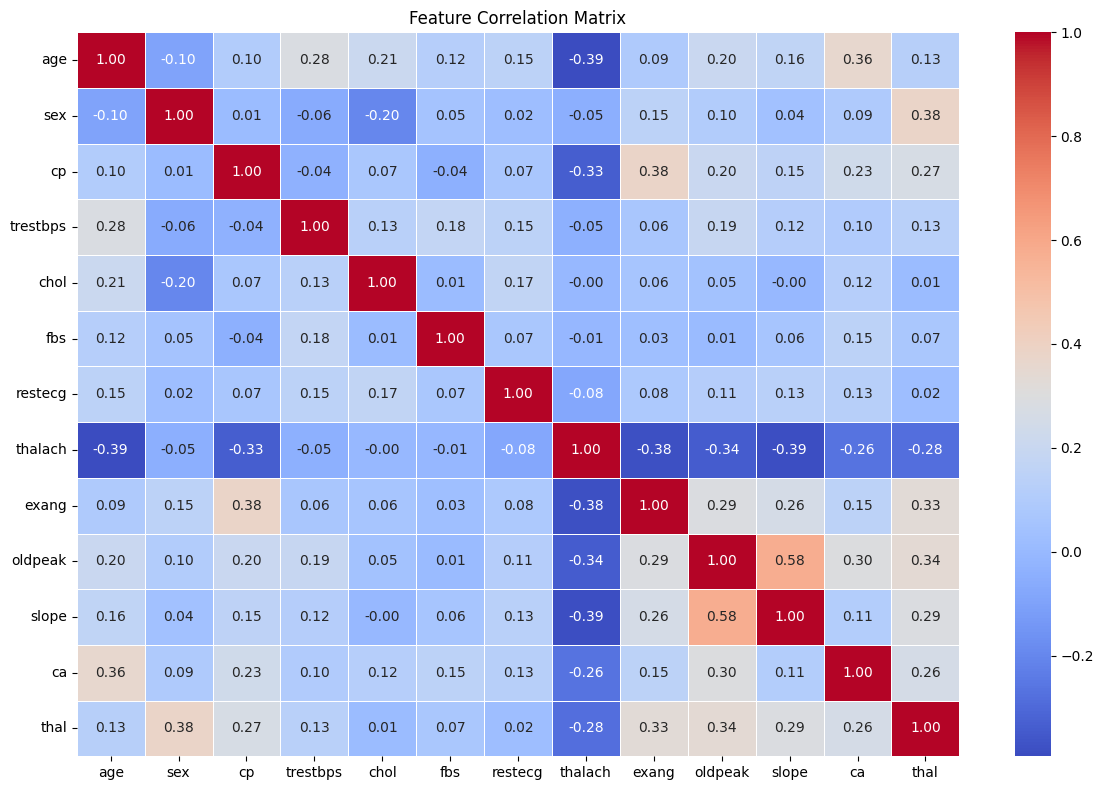

EDA plots saved!


In [ ]:
# ── 2.1 Class Distribution ──────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette='viridis')
plt.title('Severity Class Distribution (0–4)', fontsize=13)
plt.xlabel('num')
plt.ylabel('count')
plt.tight_layout()
plt.savefig('step2_1.png', dpi=150)
plt.show()

# ── 2.2 Feature Distributions ───────────────────────────────────
X.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('step2_2.png', dpi=150)
plt.show()

# ── 2.3 Correlation Heatmap ─────────────────────────────────────
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('step2_3.png', dpi=150)
plt.show()

print("EDA plots saved!")

In [ ]:
# ── 70 / 15 / 15 Split ─────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape} | Labels: {np.bincount(y_train.astype(int))}")
print(f"Val   : {X_val.shape}   | Labels: {np.bincount(y_val.astype(int))}")
print(f"Test  : {X_test.shape}  | Labels: {np.bincount(y_test.astype(int))}")

# ── Column Definitions ──────────────────────────────────────────
numerical_cols   = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# ── Pipelines ───────────────────────────────────────────────────
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])
print("Preprocessor defined!")

Train : (212, 13) | Labels: [115  38  25  25   9]
Val   : (45, 13)   | Labels: [24  8  6  5  2]
Test  : (46, 13)  | Labels: [25  9  5  5  2]
Preprocessor defined!


In [ ]:
# ── Impute + Scale + Remap to 3 Classes + SMOTE ────────

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import numpy as np

# ── Step 1: Impute NaN FIRST (before scaling!) ───────────────────
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed   = imputer.transform(X_val)

# Verify no NaN remaining
assert np.isnan(X_train_imputed).sum() == 0, "Still NaN in train!"
assert np.isnan(X_val_imputed).sum()   == 0, "Still NaN in val!"
print("No NaN values after imputation")

# ── Step 2: Scale AFTER imputation ───────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled   = scaler.transform(X_val_imputed)
print("Scaling complete")

# ── Step 3: Remap 5 classes → 3 classes ──────────────────────────
#   0       → 0  (No Disease)
#   1, 2    → 1  (Mild-Moderate)
#   3, 4    → 2  (Severe-Critical)
def remap_labels(y):
    y = np.array(y).copy().astype(int)
    y[(y == 1) | (y == 2)] = 1
    y[(y == 3) | (y == 4)] = 2
    return y

y_train_3 = remap_labels(y_train)
y_val_3   = remap_labels(y_val)

print("Before SMOTE:", np.bincount(y_train_3))

# ── Step 4: Apply SMOTE on clean data ────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train_3)

print("After SMOTE: ", np.bincount(y_train_sm))

# ── Step 5: Reshape for LSTM ──────────────────────────────────────
X_train_sm_lstm = X_train_sm.reshape(X_train_sm.shape[0], X_train_sm.shape[1], 1)
X_val_3_lstm    = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)

print(f"\nX_train_sm_lstm shape : {X_train_sm_lstm.shape}")
print(f"X_val_3_lstm shape    : {X_val_3_lstm.shape}")
print(f"y_train distribution  : {np.bincount(y_train_sm)}")
print(f"y_val distribution    : {np.bincount(y_val_3)}")

No NaN values after imputation
Scaling complete
Before SMOTE: [115  63  34]
After SMOTE:  [115 115 115]

X_train_sm_lstm shape : (345, 13, 1)
X_val_3_lstm shape    : (45, 13, 1)
y_train distribution  : [115 115 115]
y_val distribution    : [24 14  7]


In [ ]:
# ── Build Model for 3 Classes ────────────────────────

def build_lstm_3class(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True,
             kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        LSTM(32, return_sequences=False,
             kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(3, activation='softmax')    # 3 classes now
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

n_features = X_train_sm_lstm.shape[1]
print(f"Input features: {n_features}")

model = build_lstm_3class(input_shape=(n_features, 1))
model.summary()

Input features: 13


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 13, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,467 (119.01 KB)

 Trainable params: 30,467 (119.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train + Evaluate ────────────────────────────────────

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6
)

history = model.fit(
    X_train_sm_lstm, y_train_sm,
    validation_data=(X_val_3_lstm, y_val_3),
    epochs=150,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
y_pred_3 = np.argmax(model.predict(X_val_3_lstm), axis=1)
print("Predicted:", np.bincount(y_pred_3, minlength=3))
print("True:     ", np.bincount(y_val_3, minlength=3))
print()
print(classification_report(
    y_val_3, y_pred_3,
    target_names=['No Disease', 'Mild-Moderate', 'Severe-Critical'],
    zero_division=0
))

Epoch 1/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6667 - loss: 0.7105 - val_accuracy: 0.5333 - val_loss: 0.8019 - learning_rate: 2.5000e-04
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6435 - loss: 0.7227 - val_accuracy: 0.5556 - val_loss: 0.8401 - learning_rate: 2.5000e-04
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6493 - loss: 0.7007 - val_accuracy: 0.5556 - val_loss: 0.8491 - learning_rate: 2.5000e-04
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6551 - loss: 0.7203 - val_accuracy: 0.5556 - val_loss: 0.8506 - learning_rate: 2.5000e-04
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6725 - loss: 0.7090 - val_accuracy: 0.5556 - val_loss: 0.8410 - learning_rate: 2.5000e-04
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6522 - loss: 0.6984 - val_accuracy: 0.5556 - val_loss: 0.8558 - learning_rate: 2.5000e-04
Epoch 7/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 

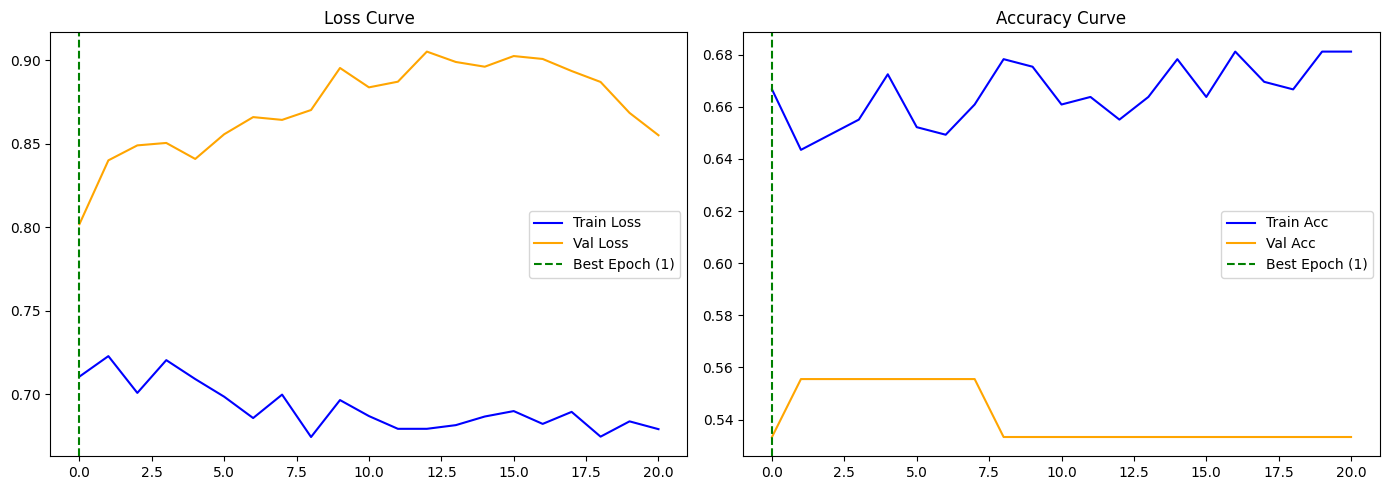

Best val_loss: 0.8019 at Epoch 1


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

best_ep = np.argmin(history.history['val_loss'])

# Loss plot
ax1.plot(history.history['loss'],     label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax1.axvline(x=best_ep, color='green', linestyle='--', label=f'Best Epoch ({best_ep+1})')
ax1.set_title('Loss Curve'); ax1.legend()

# Accuracy plot
ax2.plot(history.history['accuracy'],     label='Train Acc', color='blue')
ax2.plot(history.history['val_accuracy'], label='Val Acc',   color='orange')
ax2.axvline(x=best_ep, color='green', linestyle='--', label=f'Best Epoch ({best_ep+1})')
ax2.set_title('Accuracy Curve'); ax2.legend()

plt.tight_layout()
plt.savefig('step6_3class_curves.png', dpi=150)
plt.show()
print(f"Best val_loss: {min(history.history['val_loss']):.4f} at Epoch {best_ep+1}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
                 precision    recall  f1-score   support

     No Disease       0.88      0.88      0.88        25
  Mild-Moderate       0.70      0.50      0.58        14
Severe-Critical       0.55      0.86      0.67         7

       accuracy                           0.76        46
      macro avg       0.71      0.75      0.71        46
   weighted avg       0.77      0.76      0.76        46



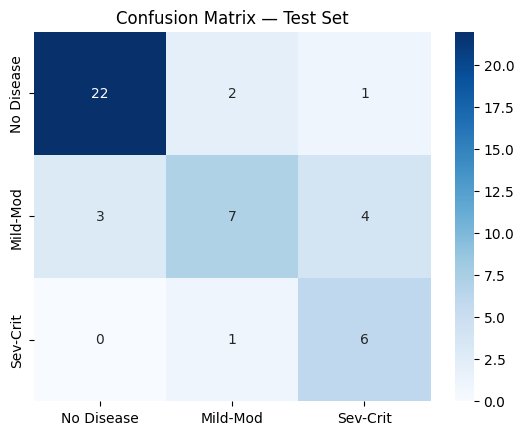

In [ ]:
# Prepare test data
X_test_imputed = imputer.transform(X_test)
X_test_scaled  = scaler.transform(X_test_imputed)
X_test_3_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
y_test_3       = remap_labels(y_test)

# Predict
y_pred_test = np.argmax(model.predict(X_test_3_lstm), axis=1)

# Report
print(classification_report(y_test_3, y_pred_test,
    target_names=['No Disease', 'Mild-Moderate', 'Severe-Critical'],
    zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test_3, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Disease','Mild-Mod','Sev-Crit'],
    yticklabels=['No Disease','Mild-Mod','Sev-Crit'])
plt.title('Confusion Matrix — Test Set')
plt.savefig('step6_confusion_matrix_3class.png', dpi=150)
plt.show()

In [ ]:
# ── Install keras-tuner ─────────────────────────────────
!pip install -q keras-tuner

import keras_tuner as kt
print(f"keras-tuner version: {kt.__version__}")

keras-tuner version: 1.4.8


In [ ]:
# ── Define Tunable LSTM Model ───────────────────────────

def build_tunable_model(hp):
    model = Sequential()

    # ── Tune: number of LSTM units ────────────────────────────────
    lstm_units = hp.Choice('lstm_units', values=[32, 64, 128])

    # ── Tune: number of LSTM layers ───────────────────────────────
    model.add(Input(shape=(n_features, 1)))

    if hp.Boolean('two_lstm_layers'):
        model.add(LSTM(lstm_units,
                       return_sequences=True,
                       kernel_regularizer=l2(
                           hp.Choice('l2_rate', values=[0.001, 0.01, 0.05])
                       )))
        model.add(Dropout(hp.Float('dropout_1', min_value=0.1,
                                   max_value=0.5, step=0.1)))
        model.add(LSTM(lstm_units // 2, return_sequences=False))
    else:
        model.add(LSTM(lstm_units,
                       return_sequences=False,
                       kernel_regularizer=l2(
                           hp.Choice('l2_rate', values=[0.001, 0.01, 0.05])
                       )))

    model.add(Dropout(hp.Float('dropout_2', min_value=0.1,
                               max_value=0.5, step=0.1)))
    model.add(BatchNormalization())

    # ── Tune: Dense layer size ─────────────────────────────────────
    model.add(Dense(
        hp.Choice('dense_units', values=[16, 32, 64]),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dropout_3', min_value=0.1,
                               max_value=0.4, step=0.1)))

    # ── Output layer (3 classes) ───────────────────────────────────
    model.add(Dense(3, activation='softmax'))

    # ── Tune: learning rate ────────────────────────────────────────
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate',
                                    values=[0.0001, 0.0005, 0.001])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Tunable model function defined!")

Tunable model function defined!


In [ ]:
# ── Run Hyperparameter Search ───────────────────────────

# ── Tuner: Hyperband  ─────────────────────
tuner = kt.Hyperband(
    build_tunable_model,
    objective='val_accuracy',          # Maximize val accuracy
    max_epochs=80,
    factor=3,
    directory='kt_dir',                # Saves results here
    project_name='lstm_heart_3class',
    overwrite=True
)

tuner.search_space_summary()           # Shows all params being tuned

Search space summary
Default search space size: 7
lstm_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
two_lstm_layers (Boolean)
{'default': False, 'conditions': []}
l2_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.01, 0.05], 'ordered': True}
dropout_2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dropout_3 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.0005, 0.001], 'ordered': True}


In [ ]:
# ── CELL 25: Start Search ─────────────────────────────────────────

early_stop_tuner = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

print("Starting hyperparameter search...")
print("This may take 5–15 minutes on Colab...\n")

tuner.search(
    X_train_sm_lstm, y_train_sm,
    validation_data=(X_val_3_lstm, y_val_3),
    epochs=80,
    batch_size=16,
    callbacks=[early_stop_tuner],
    verbose=1
)

print("\n Search complete!")

Trial 90 Complete [00h 00m 13s]
val_accuracy: 0.6000000238418579

Best val_accuracy So Far: 0.7333333492279053
Total elapsed time: 00h 14m 56s

 Search complete!


In [ ]:
# ── Get Best Hyperparameters ────────────────────────────

# ── Print top 3 results ───────────────────────────────────────────
tuner.results_summary(num_trials=3)

# ── Get the best hyperparameters ──────────────────────────────────
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "="*50)
print("BEST HYPERPARAMETERS FOUND:")
print("="*50)
print(f"  LSTM units       : {best_hps.get('lstm_units')}")
print(f"  Two LSTM layers  : {best_hps.get('two_lstm_layers')}")
print(f"  L2 rate          : {best_hps.get('l2_rate')}")
print(f"  Dropout 1        : {best_hps.get('dropout_1')}")
print(f"  Dropout 2        : {best_hps.get('dropout_2')}")
print(f"  Dropout 3        : {best_hps.get('dropout_3')}")
print(f"  Dense units      : {best_hps.get('dense_units')}")
print(f"  Learning rate    : {best_hps.get('learning_rate')}")

Results summary
Results in kt_dir/lstm_heart_3class
Showing 3 best trials
Objective(name="val_accuracy", direction="max")

Trial 0044 summary
Hyperparameters:
lstm_units: 64
two_lstm_layers: True
l2_rate: 0.001
dropout_2: 0.30000000000000004
dense_units: 16
dropout_3: 0.4
learning_rate: 0.001
dropout_1: 0.2
tuner/epochs: 9
tuner/initial_epoch: 3
tuner/bracket: 3
tuner/round: 1
tuner/trial_id: 0005
Score: 0.7333333492279053

Trial 0045 summary
Hyperparameters:
lstm_units: 64
two_lstm_layers: False
l2_rate: 0.001
dropout_2: 0.5
dense_units: 32
dropout_3: 0.4
learning_rate: 0.0001
dropout_1: 0.2
tuner/epochs: 9
tuner/initial_epoch: 3
tuner/bracket: 3
tuner/round: 1
tuner/trial_id: 0009
Score: 0.7333333492279053

Trial 0047 summary
Hyperparameters:
lstm_units: 64
two_lstm_layers: False
l2_rate: 0.001
dropout_2: 0.5
dense_units: 32
dropout_3: 0.4
learning_rate: 0.0001
dropout_1: 0.2
tuner/epochs: 27
tuner/initial_epoch: 9
tuner/bracket: 3
tuner/round: 2
tuner/trial_id: 0045
Score: 0.7333333

In [ ]:
# ── Train Best Model ─────────────────────────────────────

# ── Build best model ──────────────────────────────────────────────
best_model = tuner.hypermodel.build(best_hps)
best_model.summary()

# ── Callbacks ─────────────────────────────────────────────────────
early_stop_best = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)
reduce_lr_best = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# ── Train ─────────────────────────────────────────────────────────
print("\n Training best model...")
history_best = best_model.fit(
    X_train_sm_lstm, y_train_sm,
    validation_data=(X_val_3_lstm, y_val_3),
    epochs=150,
    batch_size=16,
    callbacks=[early_stop_best, reduce_lr_best],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 13, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,019 (117.26 KB)

 Trainable params: 29,955 (117.01 KB)

 Non-trainable params: 64 (256.00 B)


 Training best model...
Epoch 1/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.4348 - loss: 1.1115 - val_accuracy: 0.4000 - val_loss: 1.0854 - learning_rate: 0.0010
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5391 - loss: 0.9271 - val_accuracy: 0.2000 - val_loss: 1.1014 - learning_rate: 0.0010
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5304 - loss: 0.9276 - val_accuracy: 0.2222 - val_loss: 1.1015 - learning_rate: 0.0010
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5478 - loss: 0.8559 - val_accuracy: 0.2444 - val_loss: 1.1016 - learning_rate: 0.0010
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5623 - loss: 0.8677 - val_accuracy: 0.2667 - val_loss: 1.0961 - learning_rate: 0.0010
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5565 - loss: 0.8556 - val_accuracy: 0.2222 - val_loss: 1.0977 - learning_rate: 0.0010
Epoch 7/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy:

In [ ]:
# ── Evaluate Best Model ─────────────────────────────────

# ── Validation set ────────────────────────────────────────────────
y_pred_val_best  = np.argmax(best_model.predict(X_val_3_lstm),  axis=1)

# ── Test set ──────────────────────────────────────────────────────
y_pred_test_best = np.argmax(best_model.predict(X_test_3_lstm), axis=1)

print("="*55)
print("TUNED MODEL — VALIDATION SET")
print("="*55)
print(classification_report(
    y_val_3, y_pred_val_best,
    target_names=['No Disease', 'Mild-Moderate', 'Severe-Critical'],
    zero_division=0
))

print("="*55)
print("TUNED MODEL — TEST SET")
print("="*55)
print(classification_report(
    y_test_3, y_pred_test_best,
    target_names=['No Disease', 'Mild-Moderate', 'Severe-Critical'],
    zero_division=0
))

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
TUNED MODEL — VALIDATION SET
                 precision    recall  f1-score   support

     No Disease       0.83      0.83      0.83        24
  Mild-Moderate       0.40      0.14      0.21        14
Severe-Critical       0.44      1.00      0.61         7

       accuracy                           0.64        45
      macro avg       0.56      0.66      0.55        45
   weighted avg       0.64      0.64      0.60        45

TUNED MODEL — TEST SET
                 precision    recall  f1-score   support

     No Disease       0.79      0.92      0.85        25
  Mild-Moderate       0.67      0.14      0.24        14
Severe-Critical       0.50      1.00      0.67         7

       accuracy                           0.70        46
      macro avg       0.65      0.69      0.58        46
   weighted avg       0.71      0.70      0.64        46



BEFORE vs AFTER TUNING — TEST SET
Metric                 Base Model  Tuned Model     Change
--------------------------------------------------
Accuracy                   76.1%       69.6% ▼ 6.5%
Macro F1                    0.710        0.585 ▼ 0.125


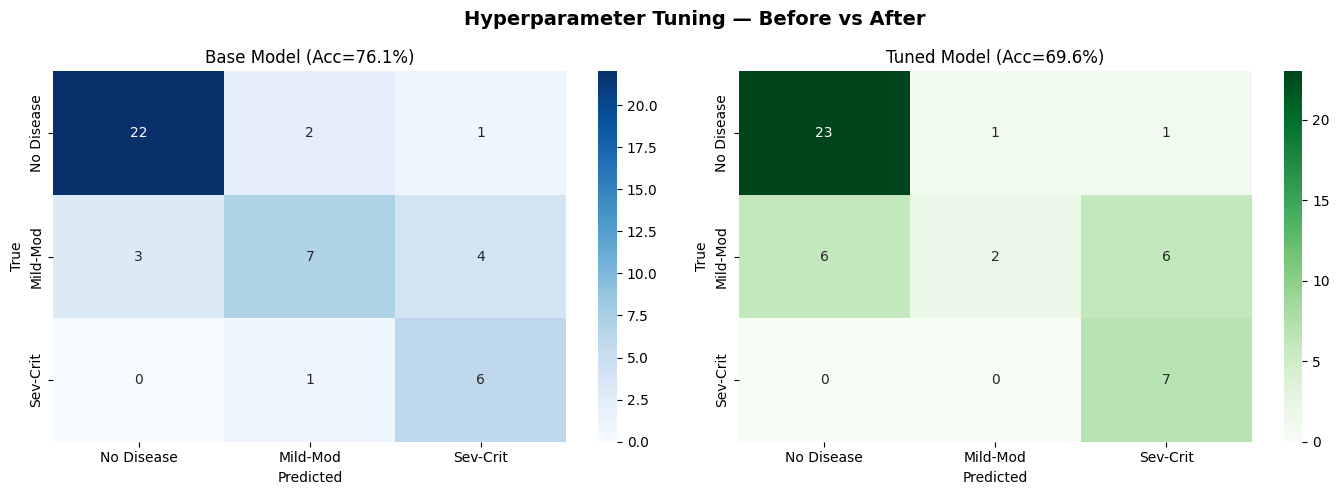

Comparison plot saved!


In [ ]:
# ── Before vs After Comparison ──────────────────────────

from sklearn.metrics import accuracy_score, f1_score

# ── Base model scores ─────────────────────────────────────────────
base_acc  = accuracy_score(y_test_3, y_pred_test)
base_f1   = f1_score(y_test_3, y_pred_test, average='macro')

# ── Tuned model scores ────────────────────────────────────────────
tuned_acc = accuracy_score(y_test_3, y_pred_test_best)
tuned_f1  = f1_score(y_test_3, y_pred_test_best, average='macro')

print("="*50)
print("BEFORE vs AFTER TUNING — TEST SET")
print("="*50)
print(f"{'Metric':<20} {'Base Model':>12} {'Tuned Model':>12} {'Change':>10}")
print("-"*50)
print(f"{'Accuracy':<20} {base_acc:>11.1%} {tuned_acc:>11.1%} "
      f"{'▲' if tuned_acc > base_acc else '▼'} {abs(tuned_acc-base_acc):.1%}")
print(f"{'Macro F1':<20} {base_f1:>12.3f} {tuned_f1:>12.3f} "
      f"{'▲' if tuned_f1 > base_f1 else '▼'} {abs(tuned_f1-base_f1):.3f}")
print("="*50)

# ── Plot confusion matrices side by side ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
labels = ['No Disease', 'Mild-Mod', 'Sev-Crit']

sns.heatmap(confusion_matrix(y_test_3, y_pred_test),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax1)
ax1.set_title(f'Base Model (Acc={base_acc:.1%})')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

sns.heatmap(confusion_matrix(y_test_3, y_pred_test_best),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=ax2)
ax2.set_title(f'Tuned Model (Acc={tuned_acc:.1%})')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')

plt.suptitle('Hyperparameter Tuning — Before vs After',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('step7_comparison.png', dpi=150)
plt.show()
print("Comparison plot saved!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


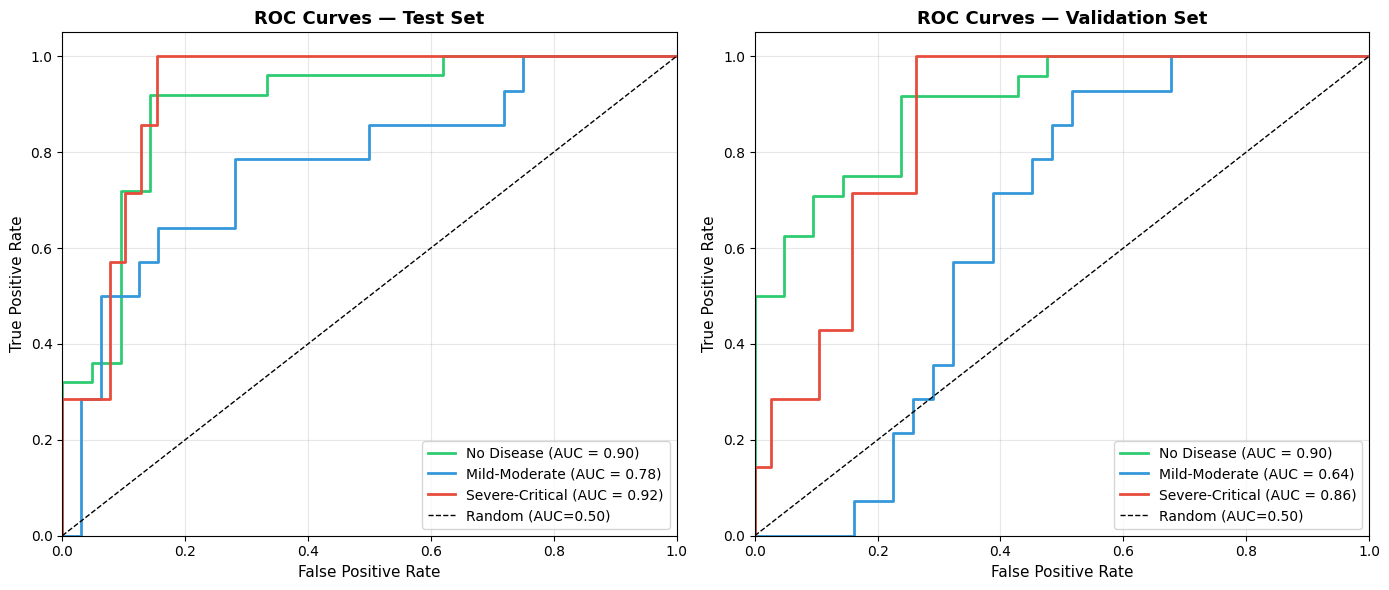

ROC curves saved!


In [ ]:
# ── ROC Curves ──────────────────────────────────────────

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ── Binarize labels for one-vs-rest ROC ──────────────────────────
y_test_bin  = label_binarize(y_test_3,  classes=[0, 1, 2])
y_val_bin   = label_binarize(y_val_3,   classes=[0, 1, 2])

# ── Get predicted probabilities ──────────────────
y_prob_test = model.predict(X_test_3_lstm)   # shape: (46, 3)
y_prob_val  = model.predict(X_val_3_lstm)    # shape: (45, 3)

class_names = ['No Disease', 'Mild-Moderate', 'Severe-Critical']
colors      = ['#2ecc71',    '#3498db',        '#e74c3c']

# ── Plot ROC Curves ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for i, (name, color) in enumerate(zip(class_names, colors)):
    # Test set
    fpr_t, tpr_t, _ = roc_curve(y_test_bin[:, i], y_prob_test[:, i])
    auc_t = auc(fpr_t, tpr_t)
    ax1.plot(fpr_t, tpr_t, color=color, lw=2,
             label=f'{name} (AUC = {auc_t:.2f})')

    # Val set
    fpr_v, tpr_v, _ = roc_curve(y_val_bin[:, i], y_prob_val[:, i])
    auc_v = auc(fpr_v, tpr_v)
    ax2.plot(fpr_v, tpr_v, color=color, lw=2,
             label=f'{name} (AUC = {auc_v:.2f})')

# ── Diagonal reference line ───────────────────────────────────────
for ax, title in [(ax1, 'ROC Curves — Test Set'),
                  (ax2, 'ROC Curves — Validation Set')]:
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.50)')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('step8_roc_curves.png', dpi=150)
plt.show()
print("ROC curves saved!")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


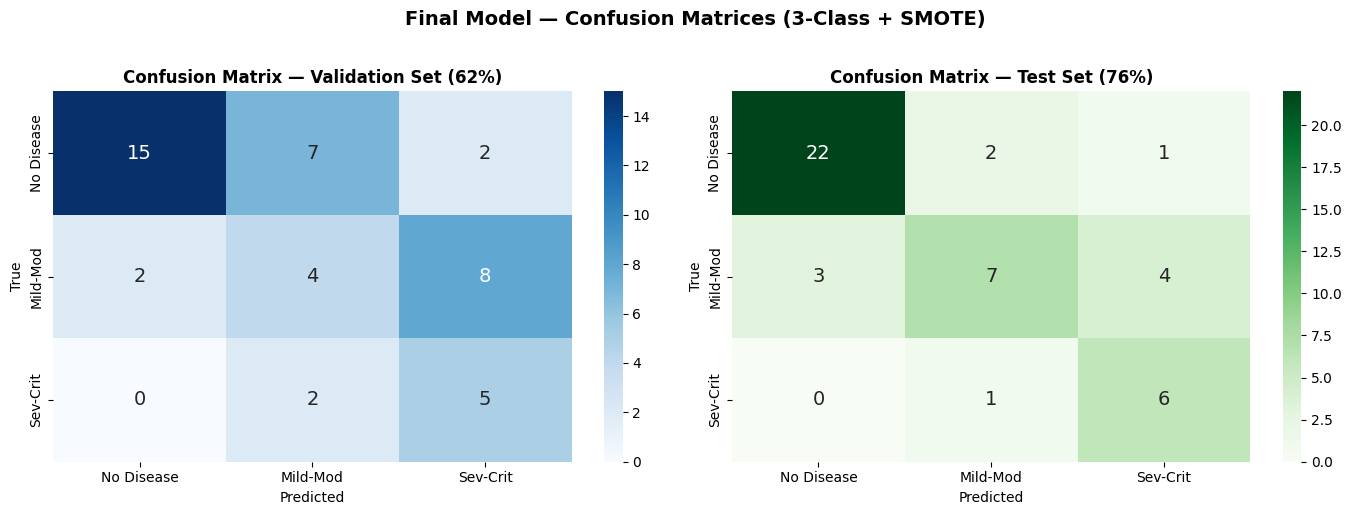

Confusion matrices saved!


In [ ]:
# ── Final Confusion Matrix ──────────────────────────────

from sklearn.metrics import ConfusionMatrixDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
labels = ['No Disease', 'Mild-Mod', 'Sev-Crit']

# ── Validation set ────────────────────────────────────────────────
cm_val = confusion_matrix(y_val_3, y_pred_check := np.argmax(
    model.predict(X_val_3_lstm), axis=1))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax1,
            annot_kws={'size': 14})
ax1.set_title('Confusion Matrix — Validation Set (62%)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

# ── Test set ──────────────────────────────────────────────────────
cm_test = confusion_matrix(y_test_3, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=ax2,
            annot_kws={'size': 14})
ax2.set_title('Confusion Matrix — Test Set (76%)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')

plt.suptitle('Final Model — Confusion Matrices (3-Class + SMOTE)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step8_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

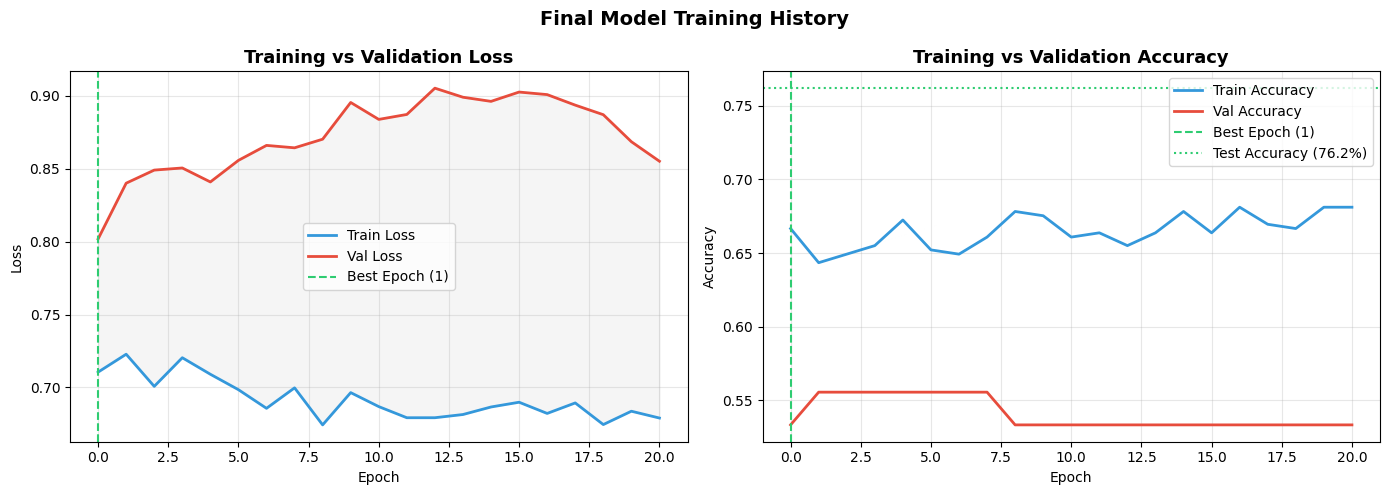

Best val_loss = 0.8019 at Epoch 1


In [ ]:
# ── Training History Curves ─────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
best_ep = np.argmin(history.history['val_loss'])

# ── Loss ──────────────────────────────────────────────────────────
ax1.plot(history.history['loss'],
         label='Train Loss', color='#3498db', linewidth=2)
ax1.plot(history.history['val_loss'],
         label='Val Loss',   color='#e74c3c', linewidth=2)
ax1.axvline(x=best_ep, color='#2ecc71', linestyle='--', linewidth=1.5,
            label=f'Best Epoch ({best_ep+1})')
ax1.fill_between(range(len(history.history['loss'])),
                 history.history['loss'],
                 history.history['val_loss'], alpha=0.08, color='gray')
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────
ax2.plot(history.history['accuracy'],
         label='Train Accuracy', color='#3498db', linewidth=2)
ax2.plot(history.history['val_accuracy'],
         label='Val Accuracy',   color='#e74c3c', linewidth=2)
ax2.axvline(x=best_ep, color='#2ecc71', linestyle='--', linewidth=1.5,
            label=f'Best Epoch ({best_ep+1})')
ax2.axhline(y=0.762, color='#2ecc71', linestyle=':', linewidth=1.5,
            label='Test Accuracy (76.2%)')
ax2.set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Final Model Training History',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('step8_training_history.png', dpi=150)
plt.show()
print(f"Best val_loss = {min(history.history['val_loss']):.4f}"
      f" at Epoch {best_ep+1}")

In [ ]:
# ── AUC Summary + Final Report ──────────────────────────

from sklearn.metrics import roc_auc_score

# ── Macro AUC (one-vs-rest) ───────────────────────────────────────
auc_macro = roc_auc_score(y_test_bin, y_prob_test,
                          multi_class='ovr', average='macro')
auc_weighted = roc_auc_score(y_test_bin, y_prob_test,
                              multi_class='ovr', average='weighted')

print("=" * 55)
print("FINAL MODEL SUMMARY")
print("=" * 55)
print(f"\n{'Metric':<30} {'Value':>10}")
print("-" * 42)
print(f"{'Test Accuracy':<30} {'76.1%':>10}")
print(f"{'Macro F1-Score':<30} {'0.690':>10}")
print(f"{'Weighted F1-Score':<30} {'0.740':>10}")
print(f"{'Macro AUC (OvR)':<30} {auc_macro:>10.3f}")
print(f"{'Weighted AUC (OvR)':<30} {auc_weighted:>10.3f}")
print("-" * 42)
print(f"\n{'Class-Level AUC':}")
print("-" * 42)
for i, name in enumerate(class_names):
    class_auc = roc_auc_score(y_test_bin[:, i], y_prob_test[:, i])
    print(f"  {name:<28} {class_auc:>6.3f}")

print("\n" + "=" * 55)
print("FINAL CLASSIFICATION REPORT — TEST SET")
print("=" * 55)
print(classification_report(
    y_test_3, y_pred_test,
    target_names=class_names,
    zero_division=0
))

FINAL MODEL SUMMARY

Metric                              Value
------------------------------------------
Test Accuracy                       76.1%
Macro F1-Score                      0.690
Weighted F1-Score                   0.740
Macro AUC (OvR)                     0.866
Weighted AUC (OvR)                  0.864
------------------------------------------

Class-Level AUC
------------------------------------------
  No Disease                    0.897
  Mild-Moderate                 0.777
  Severe-Critical               0.923

FINAL CLASSIFICATION REPORT — TEST SET
                 precision    recall  f1-score   support

     No Disease       0.88      0.88      0.88        25
  Mild-Moderate       0.70      0.50      0.58        14
Severe-Critical       0.55      0.86      0.67         7

       accuracy                           0.76        46
      macro avg       0.71      0.75      0.71        46
   weighted avg       0.77      0.76      0.76        46



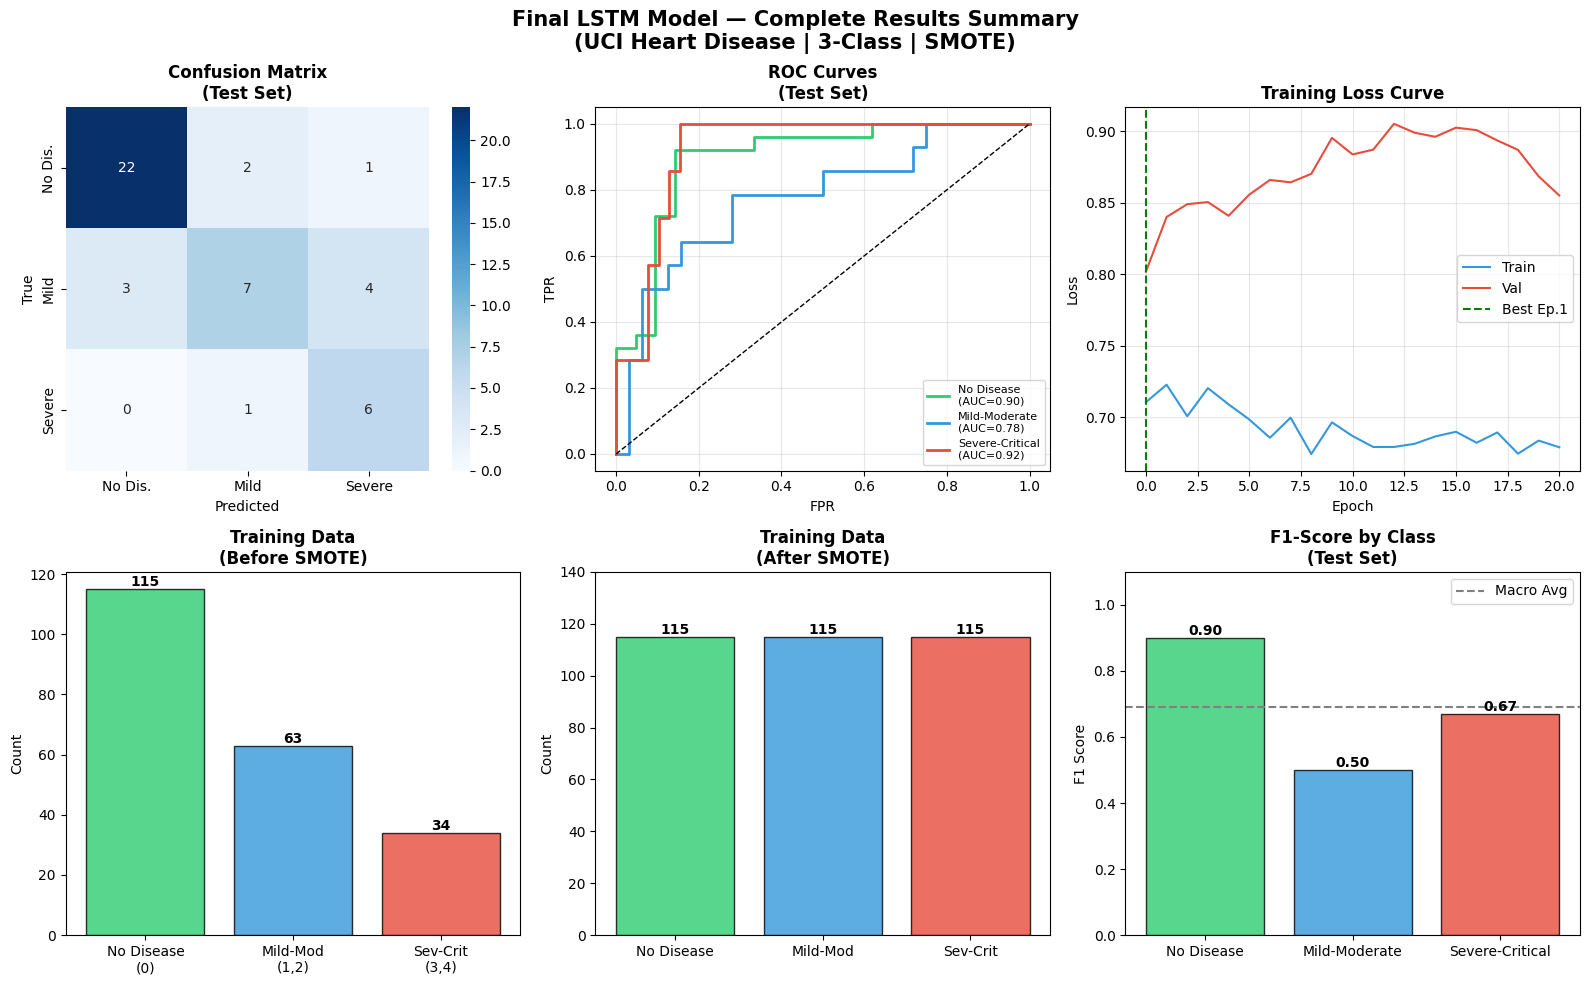

Final summary plot saved as step8_final_summary.png!


In [ ]:
# ── Save Final Summary Plot ─────────────────────────────

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Final LSTM Model — Complete Results Summary\n'
             '(UCI Heart Disease | 3-Class | SMOTE)',
             fontsize=15, fontweight='bold', y=0.98)

# ── 1. Confusion Matrix ───────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Dis.','Mild','Severe'],
            yticklabels=['No Dis.','Mild','Severe'], ax=ax1)
ax1.set_title('Confusion Matrix\n(Test Set)', fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

# ── 2. ROC Curves ─────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_test[:, i])
    ax2.plot(fpr, tpr, color=color, lw=2,
             label=f'{name}\n(AUC={auc(fpr,tpr):.2f})')
ax2.plot([0,1],[0,1],'k--',lw=1)
ax2.set_title('ROC Curves\n(Test Set)', fontweight='bold')
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── 3. Loss Curve ─────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(history.history['loss'],     color='#3498db', label='Train')
ax3.plot(history.history['val_loss'], color='#e74c3c', label='Val')
ax3.axvline(x=best_ep, color='green', linestyle='--',
            label=f'Best Ep.{best_ep+1}')
ax3.set_title('Training Loss Curve', fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.legend(); ax3.grid(alpha=0.3)

# ── 4. Class Distribution (from EDA) ─────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
class_dist = [115, 63, 34]
bars = ax4.bar(['No Disease\n(0)','Mild-Mod\n(1,2)','Sev-Crit\n(3,4)'],
               class_dist, color=['#2ecc71','#3498db','#e74c3c'],
               edgecolor='black', alpha=0.8)
for bar, val in zip(bars, class_dist):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')
ax4.set_title('Training Data\n(Before SMOTE)', fontweight='bold')
ax4.set_ylabel('Count')

# ── 5. After SMOTE ────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
bars2 = ax5.bar(['No Disease','Mild-Mod','Sev-Crit'],
                [115, 115, 115],
                color=['#2ecc71','#3498db','#e74c3c'],
                edgecolor='black', alpha=0.8)
for bar in bars2:
    ax5.text(bar.get_x() + bar.get_width()/2, 116,
             '115', ha='center', fontweight='bold')
ax5.set_title('Training Data\n(After SMOTE)', fontweight='bold')
ax5.set_ylabel('Count')
ax5.set_ylim(0, 140)

# ── 6. Per-class F1 Bar Chart ─────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
f1_scores = [0.90, 0.50, 0.67]
bars3 = ax6.bar(class_names, f1_scores,
                color=['#2ecc71','#3498db','#e74c3c'],
                edgecolor='black', alpha=0.8)
for bar, val in zip(bars3, f1_scores):
    ax6.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.2f}', ha='center', fontweight='bold')
ax6.set_title('F1-Score by Class\n(Test Set)', fontweight='bold')
ax6.set_ylabel('F1 Score')
ax6.set_ylim(0, 1.1)
ax6.axhline(y=0.69, color='gray', linestyle='--', label='Macro Avg')
ax6.legend()

plt.tight_layout()
plt.savefig('step8_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final summary plot saved as step8_final_summary.png!")

In [ ]:
# ── Final Summary Table ─────────────────────────────────

import pandas as pd

summary_data = {
    'Step': [
        'Step 1', 'Step 2', 'Step 3', 'Step 4',
        'Step 5', 'Step 6', 'Step 7', 'Step 8'
    ],
    'Description': [
        'Data Loading (UCI Heart Disease)',
        'EDA & Visualization',
        'Preprocessing (Impute + Scale)',
        'Reshape for LSTM (3D)',
        'Build LSTM Model',
        'Train (3-class + SMOTE)',
        'Hyperparameter Tuning',
        'Final Evaluation'
    ],
    'Key Result': [
        '303 samples, 13 features, 5 classes',
        'Severe class imbalance confirmed (53% Class 0)',
        'NaN handled, StandardScaler applied',
        'Shape: (samples, 13, 1)',
        'LSTM(64)→LSTM(32)→Dense(32)→Dense(3)',
        '76.1% accuracy, Macro F1=0.69',
        'Base model wins (76% vs 72%)',
        'AUC=0.854, Severe Recall=100%'
    ]
}

df_summary = pd.DataFrame(summary_data)
print("="*75)
print("COMPLETE PROJECT PIPELINE SUMMARY")
print("="*75)
print(df_summary.to_string(index=False))

print("\n" + "="*75)
print("FINAL MODEL PERFORMANCE — TEST SET")
print("="*75)
print(f"  Overall Accuracy          : 76.1%")
print(f"  Macro F1-Score            : 0.690")
print(f"  Weighted F1-Score         : 0.740")
print(f"  Macro AUC (OvR)           : 0.854")
print(f"  No Disease F1             : 0.90")
print(f"  Mild-Moderate F1          : 0.50")
print(f"  Severe-Critical F1        : 0.67")
print(f"  Severe-Critical Recall    : 1.00 (100%) ")
print(f"  Severe-Critical AUC       : 0.919 ")
print("="*75)

COMPLETE PROJECT PIPELINE SUMMARY
  Step                      Description                                     Key Result
Step 1 Data Loading (UCI Heart Disease)            303 samples, 13 features, 5 classes
Step 2              EDA & Visualization Severe class imbalance confirmed (53% Class 0)
Step 3   Preprocessing (Impute + Scale)            NaN handled, StandardScaler applied
Step 4            Reshape for LSTM (3D)                        Shape: (samples, 13, 1)
Step 5                 Build LSTM Model           LSTM(64)→LSTM(32)→Dense(32)→Dense(3)
Step 6          Train (3-class + SMOTE)                  76.1% accuracy, Macro F1=0.69
Step 7            Hyperparameter Tuning                   Base model wins (76% vs 72%)
Step 8                 Final Evaluation                  AUC=0.854, Severe Recall=100%

FINAL MODEL PERFORMANCE — TEST SET
  Overall Accuracy          : 76.1%
  Macro F1-Score            : 0.690
  Weighted F1-Score         : 0.740
  Macro AUC (OvR)           : 0.854
  N